## First analysis of noise prediction errors


#### Load dataset

In [1]:
import os
os.chdir('/clusteruy/home/jplago/mcdaa-thesis/external/diffusion-classifier')
import pandas as pd
from diffusion.datasets import get_target_dataset

dataset_name = 'cxr_test'
csv_file = '/clusteruy/home/jplago/mcdaa-thesis/datasets/test_edema_5.csv'
dataset_base_path  = '/clusteruy/home/jplago/mimic-cxr-jpg/'
prompt_path  = 'prompts/mimic_cxr_edema_invert.csv'

transform = None

dataset = get_target_dataset(dataset_name, train=False, transform=transform, csv_file=csv_file, dataset_base_path=dataset_base_path)
prompts_df = pd.read_csv(prompt_path)

In [2]:
prompts_df

,prompt,classname,classidx
0,no pulmonary edema.,0,0
1,pulmonary edema.,1,1
2,<-1>pulmonary edema.,0,2


#### One example results

In [7]:
results_tensor_path = '/clusteruy/home/jplago/mcdaa-thesis/external/diffusion-classifier/data/cxr_test_edema_5_invert/vroentgen_v1_1trials_1keep_500samples_l1/0.pt'
n_classes = len(prompts_df)

In [8]:
label_prompts = prompts_df.prompt.to_list()
label_prompts = {i:x for i,x in enumerate(label_prompts)}
label_prompts

{0: 'no pulmonary edema.', 1: 'pulmonary edema.', 2: '<-1>pulmonary edema.'}

Example 0, label: 0


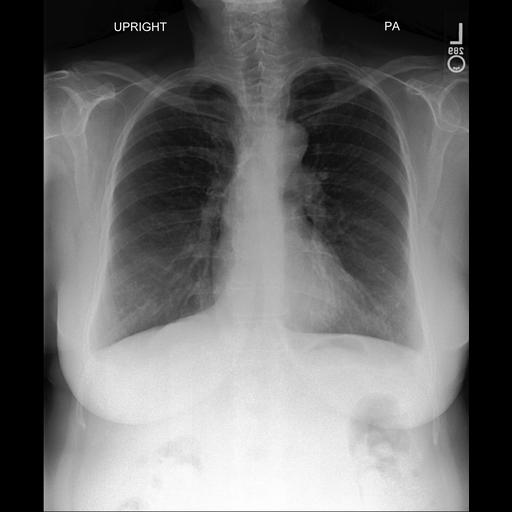

In [9]:
# Explore one result
label = dataset[0][1]
print(f'Example 0, label: {label}')
dataset[0][0]

In [10]:
# Explore errors
import torch
errors = torch.load(results_tensor_path, weights_only = False)

#n_samples = [50, 500]
n_samples = [500]
pred_label = errors['pred']
errors = errors['errors']
print(f'Predicted label: {label_prompts[pred_label]}')
print(f'True label: {label_prompts[label]}')

Predicted label: pulmonary edema.
True label: no pulmonary edema.


In [11]:
# Errors
import pandas as pd
errors_500 = pd.DataFrame({cls: errors[cls]['pred_errors'][:n_samples[0]] for cls in range(n_classes)}, index = errors[0]['t'][:n_samples[0]].tolist())
errors_500

,0,1,2
1,0.799805,0.799805,0.829102
3,0.682129,0.680176,0.851074
5,0.653809,0.655273,0.825684
7,0.656738,0.653809,0.824707
9,0.627441,0.626953,0.796875
...,...,...,...
991,0.034363,0.033997,0.053528
993,0.029617,0.030548,0.052460
995,0.032440,0.030487,0.054962
997,0.031494,0.033051,0.052002


In [12]:
# Means
mean_errors = errors_500.mean(axis = 0)
mean_errors.index = label_prompts
mean_errors

0    0.224994
1    0.222897
2    0.306982
dtype: float32

In [13]:
# Top clases
top_clss = [cls for cls,d in errors.items() if len(d['t']) > n_samples[0]]
top_clss_labels = [label_prompts[i] for i in top_clss]
print(top_clss_labels)

[]


<Axes: >

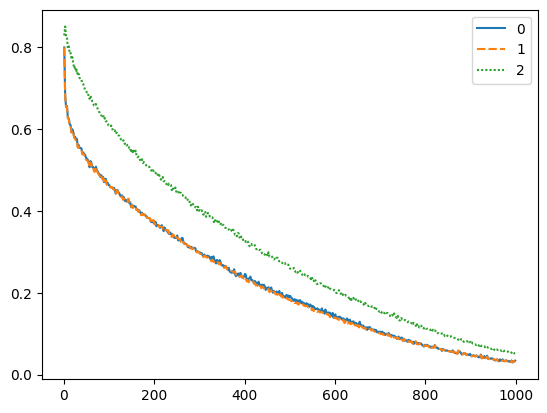

In [14]:
import seaborn as sns
sns.lineplot(errors_500)

<Axes: >

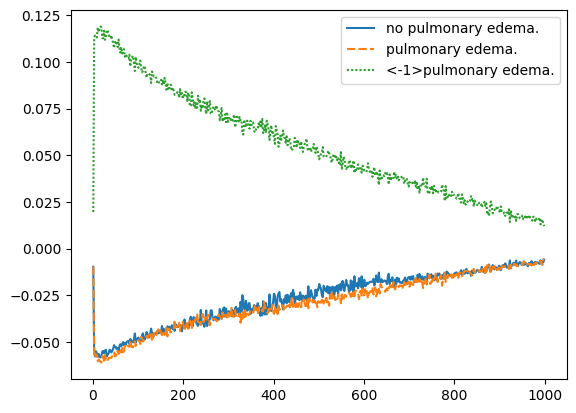

In [15]:
errors_500_means = errors_500.mean(axis = 1)
errors_500_std = errors_500.std(axis = 1)
errors_500_scaled = errors_500.apply(lambda x: (x - errors_500_means), axis = 0)
errors_500_scaled.columns = [label_prompts[i] for i in errors_500_scaled.columns]
sns.lineplot(errors_500_scaled)

#### Four examples results

In [16]:
import os
import random

results_tensor_folder = '/clusteruy/home/jplago/mcdaa-thesis/external/diffusion-classifier/data/cxr_test_edema_5_invert/vroentgen_v1_1trials_1keep_500samples_l1/'
n_classes = 3

random.seed(44)
examples = random.sample(os.listdir(results_tensor_folder), 4)
examples_inds = [int(x.split('.')[0]) for x in examples]
print(examples)

tensor_paths = [results_tensor_folder + x for x in examples]

['3.pt', '0.pt', '4.pt', '1.pt']


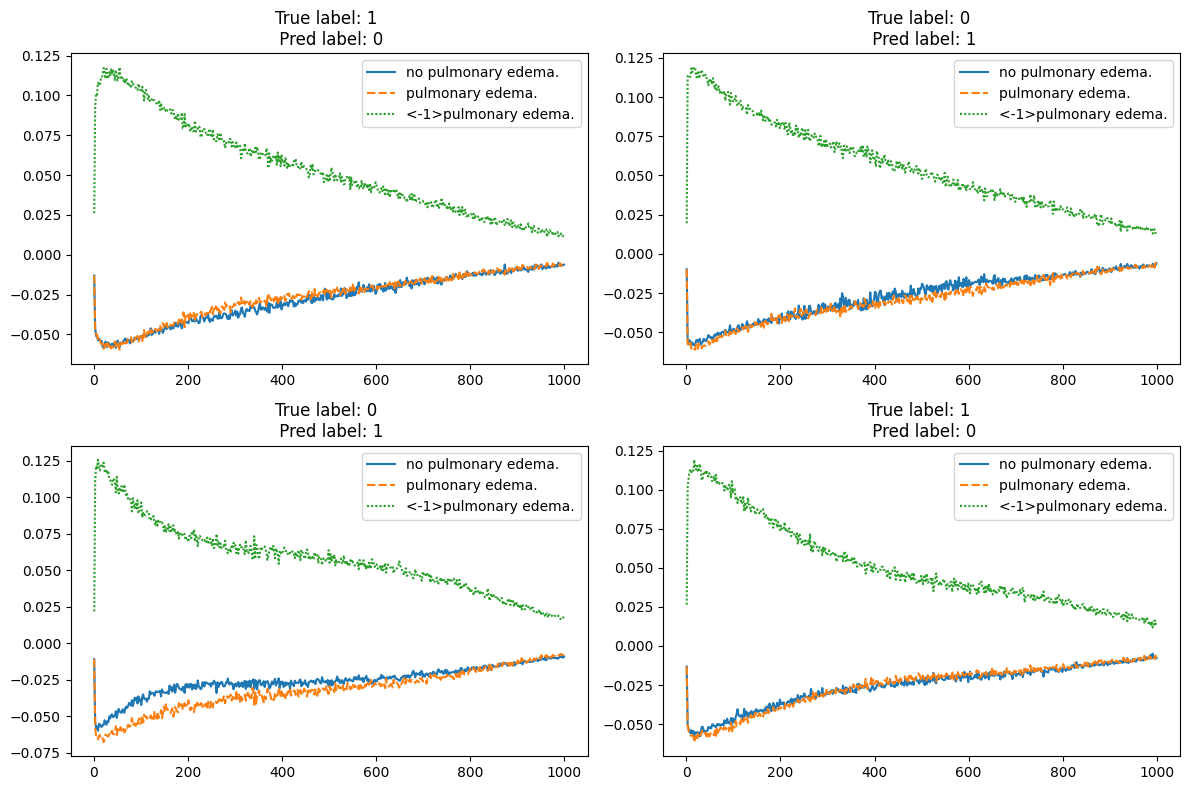

In [17]:
from matplotlib import pyplot as plt
import warnings

errors_500_scaled_list = []
errors_500_colmeans = []
predictions = []
true_labels = []
for tensor_path in tensor_paths:
    results = torch.load(tensor_path, weights_only=False)
    predictions.append(results['pred'])
    true_labels.append(results['label'])
    errors = results['errors']
    errors_500 = pd.DataFrame({cls: errors[cls]['pred_errors'][:n_samples[0]] for cls in range(n_classes)}, index = errors[0]['t'][:n_samples[0]].tolist())
    errors_500_colmeans.append(errors_500.mean(axis = 0))
    errors_500_means = errors_500.mean(axis = 1)
    errors_500_scaled = errors_500.apply(lambda x: (x - errors_500_means), axis = 0)
    errors_500_scaled.columns = [label_prompts[i] for i in errors_500_scaled.columns]
    errors_500_scaled_list.append(errors_500_scaled)

with warnings.catch_warnings():
    # Disable FutureWarnings
    warnings.simplefilter(action='ignore', category=FutureWarning)
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    for i, df in enumerate(errors_500_scaled_list):
        row = i // 2
        col = i % 2
        sns.lineplot(data=df, ax=axs[row, col])
        axs[row, col].set_title(f'True label: {true_labels[i]} \n Pred label: {predictions[i]}')
    
    
    plt.tight_layout()
    plt.show()

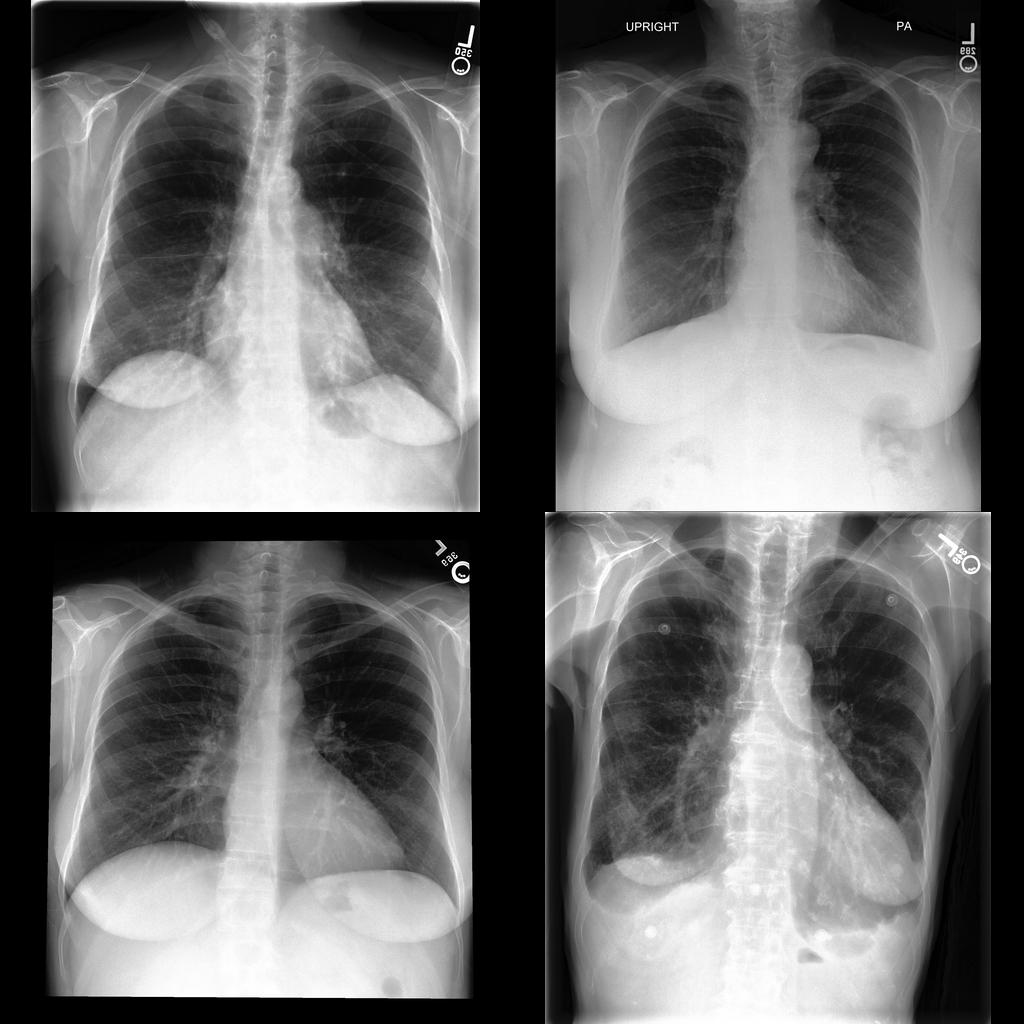

In [18]:
from PIL import Image

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid
    
images = [dataset[i][0] for i in examples_inds]
image_grid(images, 2, 2)